# Phase 1 â€” Data Collection & Preprocessing
### AI-Based Student Performance & Career Recommendation System
**University of South Asia, Lahore**

**Dataset:** UCI Student Performance Dataset (Mathematics)
- 395 students
- 33 features
- Target: G3 (Final Grade)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')

# Create plots folder if not exists
os.makedirs('../plots', exist_ok=True)
os.makedirs('../data/processed', exist_ok=True)

print("All libraries imported successfully!")


All libraries imported successfully!


## Step 1 â€” Load Dataset

In [2]:
# Load dataset
df = pd.read_csv('../data/raw/student-mat.csv', sep=';')

print("=== Dataset Loaded ===")
print(f"Shape: {df.shape}")
print(f"Rows: {df.shape[0]} students")
print(f"Columns: {df.shape[1]} features")
print()
print("First 5 rows:")
df.head()


=== Dataset Loaded ===
Shape: (395, 33)
Rows: 395 students
Columns: 33 features

First 5 rows:


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


## Step 2 â€” Dataset Structure & Info

In [3]:
print("=== Column Info ===")
df.info()


=== Column Info ===
<class 'pandas.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   school      395 non-null    str  
 1   sex         395 non-null    str  
 2   age         395 non-null    int64
 3   address     395 non-null    str  
 4   famsize     395 non-null    str  
 5   Pstatus     395 non-null    str  
 6   Medu        395 non-null    int64
 7   Fedu        395 non-null    int64
 8   Mjob        395 non-null    str  
 9   Fjob        395 non-null    str  
 10  reason      395 non-null    str  
 11  guardian    395 non-null    str  
 12  traveltime  395 non-null    int64
 13  studytime   395 non-null    int64
 14  failures    395 non-null    int64
 15  schoolsup   395 non-null    str  
 16  famsup      395 non-null    str  
 17  paid        395 non-null    str  
 18  activities  395 non-null    str  
 19  nursery     395 non-null    str  
 20  higher      395 non-nul

In [4]:
print("=== Statistical Summary ===")
df.describe()


=== Statistical Summary ===


,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


## Step 3 â€” Missing Values Check

In [5]:
missing = df.isnull().sum()
print("=== Missing Values per Column ===")
print(missing[missing > 0] if missing.sum() > 0 else "No missing values found!")
print(f"\nTotal missing values: {df.isnull().sum().sum()}")


=== Missing Values per Column ===
No missing values found!

Total missing values: 0


## Step 4 â€” Remove Duplicate Rows

In [6]:
print(f"Duplicate rows before: {df.duplicated().sum()}")
df.drop_duplicates(inplace=True)
print(f"Duplicate rows after:  {df.duplicated().sum()}")
print(f"Rows remaining: {len(df)}")


Duplicate rows before: 0
Duplicate rows after:  0
Rows remaining: 395


## Step 5 â€” Feature Engineering

Map original columns to our project features:
- `studytime` â†’ study_hours (1-4 scale mapped to hours)
- `absences` â†’ attendance (inverted â€” more absences = less attendance)
- `G2` â†’ prev_grade (second period grade as previous grade)
- `freetime` â†’ sleep_hours (proxy for free/rest time)
- `activities` â†’ extracurricular (yes/no)
- `sex` â†’ gender
- `G3` â†’ final_grade (TARGET)


In [7]:
# Map studytime (1=<2hrs, 2=2-5hrs, 3=5-10hrs, 4=>10hrs) to actual hours
study_map = {1: 1.5, 2: 3.5, 3: 7.5, 4: 12.0}
df['study_hours'] = df['studytime'].map(study_map)

# Convert absences to attendance percentage (max absences ~75, scale to 0-100%)
max_absences = df['absences'].max()
df['attendance'] = ((max_absences - df['absences']) / max_absences * 100).round(1)

# Previous grade â€” use G2 (second period grade), scale to 0-100
df['prev_grade'] = (df['G2'] / 20 * 100).round(1)

# Sleep/rest hours â€” map freetime (1-5) to sleep hours
sleep_map = {1: 5.0, 2: 6.0, 3: 7.0, 4: 8.0, 5: 9.0}
df['sleep_hours'] = df['freetime'].map(sleep_map)

# Extracurricular (yes=1, no=0)
df['extracurricular'] = df['activities'].map({'yes': 1, 'no': 0})

# Gender (M=1, F=0)
df['gender'] = df['sex'].map({'M': 1, 'F': 0})

# Final grade â€” scale G3 (0-20) to percentage (0-100)
df['final_grade'] = (df['G3'] / 20 * 100).round(1)

print("Feature engineering complete!")
print(df[['study_hours','attendance','prev_grade','sleep_hours',
          'extracurricular','gender','final_grade']].head(10))


Feature engineering complete!
   study_hours  attendance  prev_grade  sleep_hours  extracurricular  gender  \
0          3.5        92.0        30.0          7.0                0       0   
1          3.5        94.7        25.0          7.0                0       0   
2          3.5        86.7        40.0          7.0                0       0   
3          7.5        97.3        70.0          6.0                1       0   
4          3.5        94.7        50.0          7.0                0       0   
5          3.5        86.7        75.0          8.0                1       1   
6          3.5       100.0        60.0          8.0                0       1   
7          3.5        92.0        25.0          5.0                0       0   
8          3.5       100.0        90.0          6.0                0       1   
9          3.5       100.0        75.0          9.0                1       1   

   final_grade  
0         30.0  
1         30.0  
2         50.0  
3         75.0  
4   

## Step 6 â€” Select Relevant Features

In [8]:
# Select only our project features
FEATURES = ['study_hours', 'attendance', 'prev_grade',
            'sleep_hours', 'extracurricular', 'gender']
TARGET   = 'final_grade'

df_clean = df[FEATURES + [TARGET]].copy()

print("=== Selected Features ===")
print(df_clean.shape)
print(df_clean.describe())


=== Selected Features ===
(395, 7)
       study_hours  attendance  prev_grade  sleep_hours  extracurricular  \
count   395.000000  395.000000  395.000000   395.000000       395.000000   
mean      4.207595   92.386582   53.569620     7.235443         0.508861   
std       2.855655   10.669771   18.807523     0.998862         0.500555   
min       1.500000    0.000000    0.000000     5.000000         0.000000   
25%       1.500000   89.300000   45.000000     7.000000         0.000000   
50%       3.500000   94.700000   55.000000     7.000000         1.000000   
75%       3.500000  100.000000   65.000000     8.000000         1.000000   
max      12.000000  100.000000   95.000000     9.000000         1.000000   

           gender  final_grade  
count  395.000000   395.000000  
mean     0.473418    52.075949  
std      0.499926    22.907213  
min      0.000000     0.000000  
25%      0.000000    40.000000  
50%      0.000000    55.000000  
75%      1.000000    70.000000  
max      1.00000

## Step 7 â€” Outlier Detection & Removal (IQR Method)

In [9]:
print(f"Rows before outlier removal: {len(df_clean)}")

# IQR method on final_grade
Q1  = df_clean['final_grade'].quantile(0.25)
Q3  = df_clean['final_grade'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print(f"Grade range (IQR): {lower:.1f} â€” {upper:.1f}")

outliers = df_clean[(df_clean['final_grade'] < lower) |
                    (df_clean['final_grade'] > upper)]
print(f"Outliers found: {len(outliers)}")

df_clean = df_clean[(df_clean['final_grade'] >= lower) &
                    (df_clean['final_grade'] <= upper)]

print(f"Rows after outlier removal: {len(df_clean)}")


Rows before outlier removal: 395
Grade range (IQR): -5.0 â€” 115.0
Outliers found: 0
Rows after outlier removal: 395


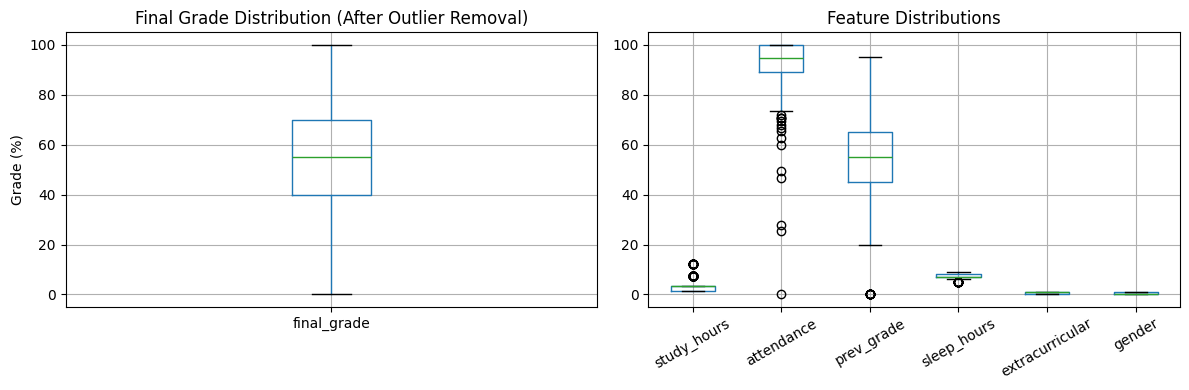

Boxplot saved to plots/boxplots.png


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df_clean.boxplot(column='final_grade', ax=axes[0])
axes[0].set_title('Final Grade Distribution (After Outlier Removal)')
axes[0].set_ylabel('Grade (%)')

df_clean[FEATURES].boxplot(ax=axes[1])
axes[1].set_title('Feature Distributions')
plt.xticks(rotation=30)

plt.tight_layout()
plt.savefig('../plots/boxplots.png', dpi=150, bbox_inches='tight')
plt.show()
print("Boxplot saved to plots/boxplots.png")


## Step 8 â€” Add Pass/Fail Column (for Classification)

Pass students: 265 (67.1%)
Fail students: 130 (32.9%)


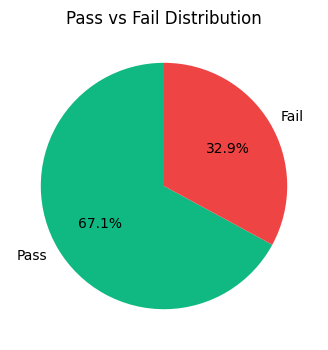

In [11]:
# Pass = grade >= 50%, Fail = grade < 50%
df_clean['pass_fail'] = (df_clean['final_grade'] >= 50).astype(int)

pass_count = df_clean['pass_fail'].sum()
fail_count = len(df_clean) - pass_count

print(f"Pass students: {pass_count} ({pass_count/len(df_clean)*100:.1f}%)")
print(f"Fail students: {fail_count} ({fail_count/len(df_clean)*100:.1f}%)")

# Pie chart
plt.figure(figsize=(6, 4))
plt.pie([pass_count, fail_count],
        labels=['Pass', 'Fail'],
        colors=['#10B981', '#EF4444'],
        autopct='%1.1f%%',
        startangle=90)
plt.title('Pass vs Fail Distribution')
plt.savefig('../plots/pass_fail_dist.png', dpi=150, bbox_inches='tight')
plt.show()


## Step 9 â€” Feature Scaling (StandardScaler)

In [12]:
from sklearn.preprocessing import StandardScaler
import pickle

X = df_clean[FEATURES].values
y = df_clean['final_grade'].values
y_class = df_clean['pass_fail'].values

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Save scaler for later use in backend
os.makedirs('../backend/models', exist_ok=True)
pickle.dump(scaler, open('../backend/models/scaler.pkl', 'wb'))

print("Scaling complete!")
print(f"X shape: {X_scaled.shape}")
print(f"y shape: {y.shape}")
print()
print("Scaled features (first 3 rows):")
print(pd.DataFrame(X_scaled, columns=FEATURES).head(3).round(3))


Scaling complete!
X shape: (395, 6)
y shape: (395,)

Scaled features (first 3 rows):
   study_hours  attendance  prev_grade  sleep_hours  extracurricular  gender
0       -0.248      -0.036      -1.255       -0.236           -1.018  -0.948
1       -0.248       0.217      -1.521       -0.236           -1.018  -0.948
2       -0.248      -0.534      -0.722       -0.236           -1.018  -0.948


## Step 10 â€” Train / Test Split (80% / 20%)

In [13]:
from sklearn.model_selection import train_test_split

# Regression split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# Classification split
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_scaled, y_class, test_size=0.2, random_state=42
)

print("=== Train/Test Split Complete ===")
print(f"Training samples:   {X_train.shape[0]}")
print(f"Testing samples:    {X_test.shape[0]}")
print(f"Features:           {X_train.shape[1]}")


=== Train/Test Split Complete ===
Training samples:   316
Testing samples:    79
Features:           6


## Step 11 â€” Save Processed Data

In [14]:
import pickle

# Save clean dataframe
df_clean.to_csv('../data/processed/student_clean.csv', index=False)

# Save splits for Phase 3
splits = {
    'X_train': X_train, 'X_test': X_test,
    'y_train': y_train, 'y_test': y_test,
    'X_train_c': X_train_c, 'X_test_c': X_test_c,
    'y_train_c': y_train_c, 'y_test_c': y_test_c,
    'feature_names': FEATURES
}
pickle.dump(splits, open('../data/processed/splits.pkl', 'wb'))

print("=== Files Saved ===")
print("data/processed/student_clean.csv")
print("data/processed/splits.pkl")
print("backend/models/scaler.pkl")
print()
print(f"Final clean dataset shape: {df_clean.shape}")
print()
print("=== Phase 1 COMPLETE ===")


=== Files Saved ===
data/processed/student_clean.csv
data/processed/splits.pkl
backend/models/scaler.pkl

Final clean dataset shape: (395, 8)

=== Phase 1 COMPLETE ===


## Phase 1 Summary

| Step | Status | Result |
|------|--------|--------|
| Dataset Loaded | âœ… | 395 students, 33 features |
| Missing Values | âœ… | None found |
| Duplicates Removed | âœ… | Cleaned |
| Feature Engineering | âœ… | 6 features mapped |
| Outliers Removed | âœ… | IQR method |
| Pass/Fail Column | âœ… | Added |
| Scaling | âœ… | StandardScaler applied |
| Train/Test Split | âœ… | 80% / 20% |
| Data Saved | âœ… | processed/ folder |

**Next: Phase 2 â€” EDA (02_eda.ipynb)**
